# Giai đoạn 10 — Chốt mô hình và mở tập test

```
┌───────────────────────────────────────────────────────────────────────┐
│                              10_ChotModel                             │
└───────────────────────────────────────────────────────────────────────┘

  ĐẦU VÀO
    • 09_TinhChinh/sieu_tham_so.json       —  cấu hình đã chốt
    • 08_TrainFinal/train_final.csv        —  3.187 dòng huấn luyện
    • 03_TachTrainTest/khaosat_test_KHOA.csv  ←  MỞ ĐÚNG MỘT LẦN
         │
         ▼
  XỬ LÝ
    1. Huấn luyện lại trên toàn bộ train_final.csv
    2. Dự đoán 102 phiếu test — lần duy nhất tập này được dùng
    3. Báo cáo TRAIN | TEST | chênh | đoán bừa | hơn bừa cho mọi Top-k
    4. So với đối chứng: đoán lớp đông nhất · model phẳng · chỉ khảo sát
         │
         ▼
  ĐẦU RA
    • 10_ChotModel/model_*.json            —  mô hình để backend dùng
    • 10_ChotModel/metrics.json · bang_ket_qua.csv
    • 10_ChotModel/hinh_10_*.png           —  5 hình
```

## Đây là lần duy nhất tập test được mở

102 phiếu khảo sát đã bị khoá từ Giai đoạn 3. Không notebook nào từ 4 đến 9 đọc nó.

Nếu sau khi nhìn kết quả test mà quay lại chỉnh mô hình rồi đo lại, tập test **không còn là tập
test** — nó thành tập validation thứ hai, và con số báo cáo sẽ lạc quan giả. Đó là lý do bước này
nằm cuối và **chỉ chạy một lần**.

## Hai chế độ, đúng như web gọi API

| Chế độ web | `fieldId` | Ý nghĩa con số |
|---|---|---|
| **Khám phá** | `null` | **năng lực thật của hệ thống** — học sinh chỉ trả lời khảo sát |
| **Tư vấn** | `0..6` | chỉ số **có điều kiện** — người dùng đã tự chọn khối |

Hai con số này **không so ngang hàng được**. Chế độ tư vấn cao hơn hẳn vì người dùng đã giải sẵn
phần khó nhất. Báo cáo phải ghi rõ điều này, nếu không người đọc sẽ tưởng hệ thống giỏi hơn thực tế.


In [1]:
import json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

warnings.filterwarnings("ignore")

PROC = Path("../data/processed")
RAW  = Path("../data/raw")
SEED = 42
np.random.seed(SEED)

# Web gửi limit=3 (web/src/app/(main)/predict/page.tsx) nên Top-3 là chỉ tiêu
# chính; Top-1/2/5 báo cáo kèm để thấy toàn cảnh.
TOP_K = (1, 2, 3, 5)

# Thư mục đầu ra trùng khít tên notebook
GIAI_DOAN = {
    1: "01_LamSachKhaoSat",
    2: "02_ChuanBiTTTH",
    3: "03_TachTrainTest",
    4: "04_MocChuan",
    5: "05_HocPhanPhoi",
    6: "06_GA_TangCuong",
    7: "07_KiemDinhGA",
    8: "08_TrainFinal",
    9: "09_TinhChinh",
    10: "10_ChotModel",
}


def thu_muc(i):
    """Thư mục đầu ra của giai đoạn i, tạo sẵn nếu chưa có."""
    p = PROC / GIAI_DOAN[i]
    p.mkdir(parents=True, exist_ok=True)
    return p


# ── Kiểu biểu đồ thống nhất cho toàn bộ báo cáo ──────────────────────────────
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 11, "axes.labelpad": 8,
    "axes.grid": True, "grid.alpha": 0.18, "grid.linestyle": "-", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": "#B0B7BF",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "xtick.color": "#4A5560", "ytick.color": "#4A5560",
    "axes.labelcolor": "#2C3E50", "text.color": "#2C3E50",
})

C_THAT = "#D64550"   # dữ liệu thật
C_GA   = "#2BA84A"   # dữ liệu tổng hợp (GA)
C_XANH = "#3B7DD8"   # nhấn mạnh chính
C_CAM  = "#E8873A"   # nhấn mạnh phụ
C_TIM  = "#8E5FBF"
C_XAM  = "#AEB6BF"   # nền / mốc so sánh
C_DAM  = "#2C3E50"
C_NHOM = plt.get_cmap("tab20")(np.linspace(0, 1, 20))


def nhan_ngang(ax, gia_tri, fmt="{:,.0f}", lui=0.012, fs=10, mau=None):
    """Ghi số ở cuối mỗi thanh ngang."""
    lim = ax.get_xlim()[1]
    for i, v in enumerate(gia_tri):
        ax.text(v + lim * lui, i, fmt.format(v), va="center", fontsize=fs,
                fontweight="bold", color=mau or C_DAM)


def nhan_doc(ax, fmt="{:,.0f}", lui=0.02, fs=10):
    """Ghi số trên đầu mỗi cột dọc."""
    lim = ax.get_ylim()[1]
    for p in ax.patches:
        h = p.get_height()
        if h and abs(h) > 1e-9:
            ax.text(p.get_x() + p.get_width() / 2, h + lim * lui, fmt.format(h),
                    ha="center", va="bottom", fontsize=fs, fontweight="bold", color=C_DAM)


def chu_thich(fig, text, y=None):
    """Dòng chú giải dưới hình — nêu KẾT LUẬN rút ra, không mô tả lại hình.

    Chú giải (legend) đặt ngoài trục bằng bbox_to_anchor y âm có thể thò xuống
    dưới đáy hình; khi đó phải hạ dòng chú thích xuống dưới nó, nếu không hai bên
    đè lên nhau (bbox_inches="tight" nới khung chứ không dời chữ ra).
    """
    if y is None:
        y = -0.02
        fig.canvas.draw()
        r = fig.canvas.get_renderer()
        hop_ds = [lg.get_window_extent(r) for lg in fig.legends]
        hop_ds += [ax.get_legend().get_window_extent(r)
                   for ax in fig.axes if ax.get_legend() is not None]
        for hop in hop_ds:
            day = hop.transformed(fig.transFigure.inverted()).y0
            if day < y:
                y = day - 0.035
    fig.text(0.5, y, text, ha="center", va="top", fontsize=10.5,
             color="#5A6672", style="italic", wrap=True)


def ngat_dong(s, n=18):
    """Ngắt chuỗi dài thành nhiều dòng thay vì cắt cụt — nhãn vẫn đọc được hết."""
    tu, dong, cur = str(s).split(), [], ""
    for t in tu:
        if len(cur) + len(t) + 1 <= n or not cur:
            cur = f"{cur} {t}".strip()
        else:
            dong.append(cur); cur = t
    if cur:
        dong.append(cur)
    return "\n".join(dong)


def cho_chu_giai(ax, ngang=True, phan=0.28):
    """Nới trục để CHỪA CHỖ cho chú giải, tránh nó đè lên cột.

    Chú giải đặt trong vùng vẽ luôn có nguy cơ chồng lên dữ liệu. Cách chắc ăn
    là nới giới hạn trục thêm `phan` rồi đặt chú giải vào khoảng trống đó.
    """
    if ngang:
        lo, hi = ax.get_xlim(); ax.set_xlim(lo, hi + (hi - lo) * phan)
    else:
        lo, hi = ax.get_ylim(); ax.set_ylim(lo, hi + (hi - lo) * phan)


def cao_theo_dong(n, moi_dong=0.26, toi_thieu=4.5, toi_da=13):
    """Chiều cao hình cho biểu đồ cột ngang — 39 nhãn cần ~11 inch, không phải 7."""
    return float(np.clip(n * moi_dong + 2.0, toi_thieu, toi_da))


def luu(fig, ra, ten, chu=None):
    if chu:
        chu_thich(fig, chu)
    fig.savefig(ra / ten, dpi=220, bbox_inches="tight", facecolor="white")
    print(f"   💾 {ten}")


def tom_tat(tieu_de, dong_ds, rong=76):
    """Bảng tóm tắt cuối notebook — mỗi giai đoạn kết thúc bằng một cái."""
    print("╔" + "═" * rong + "╗")
    print("║" + f" {tieu_de} ".center(rong) + "║")
    print("╠" + "═" * rong + "╣")
    for d in dong_ds:
        print("║ " + str(d)[: rong - 2].ljust(rong - 1) + "║")
    print("╚" + "═" * rong + "╝")

def nap(co_test=False, co_ttth=True):
    """Đọc mọi thứ notebook huấn luyện cần.

    `co_test=True` CHỈ được bật ở Giai đoạn 10 — mở tập test đúng một lần.

    Khoá "nhom" đọc từ `nganh_to_nhom` trong mapping.json. Đây là ĐIỂM KHÁC BIỆT
    DUY NHẤT giữa research2 (7 khối HUIT) và research3 (10 nhóm nghề) — nhờ vậy
    hai nhánh là thí nghiệm có đối chứng thật sự.
    """
    m = json.loads((thu_muc(1) / "mapping.json").read_text(encoding="utf-8"))
    d = {
        "likert": m["cot_likert"],
        "diem": m["cot_diem"],
        "ma_to_ten": {int(k): v for k, v in m["ma_to_ten"].items()},
        "nhom": {int(k): v for k, v in m["nganh_to_nhom"].items()},
        "ten_nhom": {int(k): v for k, v in m["ten_nhom"].items()},
        "ten_cach_nhom": m.get("ten_cach_nhom", "nhóm ngành"),
        "train": pd.read_csv(thu_muc(3) / "khaosat_train.csv"),
        "folds": json.loads((thu_muc(3) / "cv_folds.json").read_text(encoding="utf-8")),
    }
    d["ttth"] = pd.read_csv(thu_muc(2) / "ttth_sach.csv") if co_ttth else pd.DataFrame()
    if co_test:
        d["test"] = pd.read_csv(thu_muc(3) / "khaosat_test_KHOA.csv")

    nguon = [d["train"].to_hop_thi.str.split(" ").str[0]]
    if co_ttth:
        nguon.append(d["ttth"].to_hop_thi.astype(str))
    d["to_hop"] = sorted(set().union(*[set(s) for s in nguon]))
    d["nganh"] = np.sort(d["train"].ma_nganh.unique())
    d["i_nganh"] = {m_: i for i, m_ in enumerate(d["nganh"])}

    # Thống kê điểm để quy z-score. Tính trên TRAIN (+ TTTH nếu dùng), tuyệt đối
    # không đụng test — nếu không thì thông tin test rò rỉ qua bước chuẩn hoá.
    goc = [d["train"][d["diem"]]] + ([d["ttth"][d["diem"]]] if co_ttth else [])
    g = pd.concat(goc).astype(float)
    d["diem_mu"] = g.mean().values
    d["diem_sd"] = g.std().replace(0, 1).values
    return d


def dac_trung(df, D, co_khao_sat=True):
    """Ma trận 63 đặc trưng — MỘT định nghĩa duy nhất cho cả hai nguồn dữ liệu.

    `co_khao_sat=False` dùng cho hồ sơ trúng tuyển: nguồn này chỉ có điểm thi và
    tổ hợp. Cột thiếu để NaN chứ không điền bừa — XGBoost học luôn hướng rẽ cho
    giá trị thiếu ngay trong thuật toán, còn điền bừa tạo ra giá trị không có thật.
    """
    n = len(df)
    L, C_DIEM = D["likert"], D["diem"]
    th = df["to_hop_thi"].astype(str).str.split(" ").str[0].values
    Dm = df[C_DIEM].astype(float).values
    Lk = df[L].astype(float).values if co_khao_sat else np.full((n, len(L)), np.nan)

    ph = [pd.DataFrame(Lk, columns=L)]

    # Likert chuẩn hoá theo từng người: người hay chọn 4-5 và người hay chọn 2-3
    # cùng "thích logic nhất" nhưng để thô thì mô hình đọc thành hai hồ sơ khác
    # hẳn. Trừ trung bình của chính người đó thì còn lại sở thích TƯƠNG ĐỐI.
    with np.errstate(invalid="ignore"):
        mu = np.nanmean(Lk, 1, keepdims=True)
        sd = np.nanstd(Lk, 1, keepdims=True)
    sd = np.where((sd == 0) | np.isnan(sd), 1.0, sd)
    ph.append(pd.DataFrame(Lk - mu, columns=[f"ips_{c}" for c in L]))
    ph.append(pd.DataFrame({"likert_tb": mu[:, 0], "likert_dolech": sd[:, 0]}))

    ph.append(pd.DataFrame(Dm, columns=C_DIEM))
    # 8.0 môn Toán và 8.0 môn Văn không cùng ý nghĩa — quy z-score mới so được
    z = (Dm - D["diem_mu"]) / D["diem_sd"]
    ph.append(pd.DataFrame(z, columns=[f"z_{c}" for c in C_DIEM]))
    with np.errstate(invalid="ignore", divide="ignore"):
        ph.append(pd.DataFrame({
            "diem_tb": np.nanmean(Dm, 1),
            "diem_lech": np.nanmax(Dm, 1) - np.nanmin(Dm, 1),
            "z_tb": np.nanmean(z, 1),
            "z_max": np.nanmax(z, 1),
        }))

    # Tổ hợp là dữ liệu phân loại, KHÔNG có thứ tự. Mã hoá thành số (A00=0,
    # A01=1…) sẽ dạy mô hình rằng D01 "lớn hơn" A00 và trung bình A00 với B00 ra
    # A01 — vô nghĩa. One-hot tránh được: mỗi cột chỉ hỏi "có thi tổ hợp này không".
    ph.append(pd.DataFrame({f"th_{t}": (th == t).astype(float) for t in D["to_hop"]}))
    gt = ((df["gioi_tinh"] == "Nam").astype(float).values if "gioi_tinh" in df
          else np.full(n, np.nan))
    mt = (df["muc_tieu_ma"].astype(float).values if "muc_tieu_ma" in df
          else np.full(n, np.nan))
    ph.append(pd.DataFrame({"gioi_tinh_nam": gt, "muc_tieu": mt}))
    return pd.concat([p.reset_index(drop=True) for p in ph], axis=1)


def nhom_dac_trung(cols, D):
    """Gom tên cột thành 8 nhóm — dùng khi in bảng thống kê và vẽ hình."""
    L, C_DIEM = D["likert"], D["diem"]
    return {
        "Likert thô": [c for c in cols if c in L],
        "Likert chuẩn hoá theo người": [c for c in cols if c.startswith("ips_")],
        "Thống kê Likert": [c for c in cols if c in ("likert_tb", "likert_dolech")],
        "Điểm thi thô": [c for c in cols if c in C_DIEM],
        "Điểm z-score từng môn": [c for c in cols if c.startswith("z_diem_")],
        "Phái sinh từ điểm": [c for c in cols
                              if c in ("diem_tb", "diem_lech", "z_tb", "z_max")],
        "Tổ hợp xét tuyển (one-hot)": [c for c in cols if c.startswith("th_")],
        "Nhân khẩu học & mục tiêu": [c for c in cols
                                     if c in ("gioi_tinh_nam", "muc_tieu")],
    }

from xgboost import XGBClassifier


def mo_hinh(**kw):
    """XGBoost phân loại. KHÔNG ép `objective` — với nhóm 2 ngành XGBoost tự
    dùng binary:logistic (không có num_class), ép multi:softprob sẽ lỗi."""
    return XGBClassifier(**{**dict(
        max_depth=5, n_estimators=400, learning_rate=0.06, min_child_weight=3,
        subsample=0.8, colsample_bytree=0.6, reg_lambda=5.0,
        tree_method="hist", n_jobs=-1, verbosity=0, random_state=SEED), **kw})


class MoHinhNganh:
    """Mô hình gợi ý ngành. Chỉ dùng XGBoost phân loại — không có gì khác.

    Cách hoạt động, một câu:
        mô hình cho ra XÁC SUẤT cho từng ngành → bỏ những ngành không thuộc
        nhóm người dùng chọn → lấy k ngành xác suất cao nhất còn lại.

    Hai chế độ, đúng cách web gọi API:
        fieldId = None  → xếp hạng cả 39 ngành          (chế độ khám phá)
        fieldId = k     → chỉ xếp hạng ngành trong nhóm k (chế độ tư vấn)

    `rieng_nhom=True` → mỗi nhóm một mô hình nhỏ, chỉ học các ngành của nhóm đó.
    Mô hình chung phải trải sức phân biệt mọi cặp ngành, kể cả cặp ở hai nhóm
    khác hẳn nhau mà thực tế không bao giờ phải so; mô hình riêng chỉ học đúng
    việc phân biệt vài ngành trong một nhóm.
    """

    def __init__(self, D, hp=None, rieng_nhom=False, hp_nhom=None,
                 phan_tang=None):
        """`phan_tang` — dict {mã nhóm: {mã ngành: id lĩnh vực con}}.

        Với nhóm nhiều ngành, học MỘT LƯỢT 10 lớp bắt mô hình vẽ đồng thời 45
        đường ranh giới, kể cả những cặp gần như không tách được. Học hai bước
        thì bước 1 chỉ phải tách vài lĩnh vực con — việc dễ hơn và có tín hiệu
        thật — rồi bước 2 mới đi vào chỗ khó:

            P(ngành) = P(lĩnh vực con) × P(ngành | lĩnh vực con)

        Mô hình TỰ đoán lĩnh vực con, người dùng không cung cấp gì thêm, nên mốc
        đoán bừa không đổi. Đo trên khối Kinh doanh (10 ngành): 44.5% → 49.3%.
        """
        self.D = D
        self.hp = hp or {}
        self.rieng_nhom = rieng_nhom
        self.hp_nhom = hp_nhom or {}
        self.phan_tang = phan_tang or {}
        self.trong = {g: [n for n in D["nganh"] if D["nhom"][n] == g]
                      for g in sorted(set(D["nhom"].values()))}

    @staticmethod
    def _fit1(X, y, hp, w=None):
        """XGBoost 3.x bắt buộc mã lớp liền mạch 0..n-1, mà lô nhỏ có thể vắng
        vài ngành — nên phải đánh số lại rồi ánh xạ ngược lúc dự đoán."""
        co = np.unique(y)
        m = mo_hinh(**hp).fit(X, np.searchsorted(co, y), sample_weight=w)
        return m, co

    def fit(self, X, y, w=None):
        X, y = np.asarray(X), np.asarray(y)
        self.m, self.co = self._fit1(X, y, self.hp, w)
        self.m_tang = {}
        if self.rieng_nhom:
            self.m_nhom = {}
            for g, ds in self.trong.items():
                sel = np.isin(y, ds)
                if len(ds) < 2 or sel.sum() < 5 or len(np.unique(y[sel])) < 2:
                    continue
                hp_g = self.hp_nhom.get(g, self.hp)
                w_g = None if w is None else w[sel]
                self.m_nhom[g] = self._fit1(X[sel], y[sel], hp_g, w_g)
                if g in self.phan_tang:
                    self.m_tang[g] = self._fit_tang(
                        X[sel], y[sel], w_g, self.phan_tang[g], hp_g)
        return self

    def _fit_tang(self, X, y, w, ban_do, hp):
        """Hai bước: đoán lĩnh vực con trước, rồi đoán ngành trong lĩnh vực đó."""
        s = np.array([ban_do[v] for v in y])
        co_s = np.unique(s)
        if len(co_s) < 2:
            return None
        m_sub = mo_hinh(**hp).fit(X, np.searchsorted(co_s, s), sample_weight=w)
        con = {}
        for k, sv in enumerate(co_s):
            m_ = s == sv
            if len(np.unique(y[m_])) < 2:
                con[k] = (None, np.unique(y[m_]))
                continue
            con[k] = self._fit1(X[m_], y[m_], hp, None if w is None else w[m_])
        return m_sub, co_s, con

    def _rai(self, pr, co, n_dong):
        """Trải xác suất của model (chỉ vài lớp) ra đủ 39 cột ngành."""
        S = np.zeros((n_dong, len(self.D["nganh"])))
        for c, ma in enumerate(co):
            S[:, self.D["i_nganh"][ma]] = pr[:, c]
        return S

    def _diem_tang(self, X, bo):
        """P(ngành) = P(lĩnh vực con) × P(ngành | lĩnh vực con)."""
        m_sub, co_s, con = bo
        p_sub = m_sub.predict_proba(X)
        S = np.zeros((len(X), len(self.D["nganh"])))
        for k in range(len(co_s)):
            m, co = con[k]
            if m is None:
                for ma in co:
                    S[:, self.D["i_nganh"][ma]] = p_sub[:, k]
                continue
            pr = m.predict_proba(X)
            for c, ma in enumerate(co):
                S[:, self.D["i_nganh"][ma]] = p_sub[:, k] * pr[:, c]
        return S

    def diem(self, X, nhom_biet=None):
        """Xác suất trên 39 ngành. `nhom_biet` = mã nhóm người dùng chọn."""
        X = np.asarray(X)
        S = self._rai(self.m.predict_proba(X), self.co, len(X))
        if nhom_biet is None:
            return S
        nhom_biet = np.asarray(nhom_biet)
        if self.rieng_nhom:
            for g, (m, co) in self.m_nhom.items():
                sel = nhom_biet == g
                if not sel.any():
                    continue
                if self.m_tang.get(g) is not None:
                    S[sel] = self._diem_tang(X[sel], self.m_tang[g])
                else:
                    S[sel] = self._rai(m.predict_proba(X[sel]), co, int(sel.sum()))
        # Bỏ mọi ngành ngoài nhóm người dùng đã chọn
        mat_na = np.zeros_like(S)
        for i, g in enumerate(nhom_biet):
            for n in self.trong[int(g)]:
                mat_na[i, self.D["i_nganh"][n]] = 1.0
        return S * mat_na


def top_k(S, y, NG, ks=TOP_K):
    o = np.argsort(-S, axis=1)
    return {k: float(np.mean([y[i] in NG[o[i, :k]] for i in range(len(y))])) for k in ks}


def bua_toan_bo(n_lop, ks=TOP_K):
    """Đoán bừa k ngành trong toàn bộ danh mục."""
    return {k: min(k, n_lop) / n_lop for k in ks}


def bua_trong_nhom(y, nhom, ks=TOP_K):
    """Đoán bừa k ngành TRONG nhóm đúng.

    Bắt buộc báo cáo kèm: nhóm chỉ có 2 ngành thì Top-3 tự đúng 100% mà không cần
    mô hình nào. Thiếu cột này, một con số 85% có thể chỉ hơn đoán bừa vài điểm mà
    người đọc vẫn tưởng mô hình giỏi.
    """
    co = pd.Series(list(nhom.values())).value_counts()
    return {k: float(np.mean([min(k, co[nhom[m]]) / co[nhom[m]] for m in y])) for k in ks}


def ky_nang(acc, bua):
    """Phần lỗi của đoán bừa mà mô hình XOÁ ĐƯỢC.

        kỹ năng = (acc − bừa) / (1 − bừa)

    Vì sao cần chỉ số này: chia nhóm càng nhỏ thì đoán bừa càng cao, nên con số
    độ chính xác trần trụi KHÔNG so được giữa các cách chia nhóm khác nhau.
    Kỹ năng đã trừ sạch lợi thế đó — 0% là chỉ ngang đoán bừa, 100% là hoàn hảo.

    Ví dụ: 7 khối đạt 69.7% với bừa 49.2% → kỹ năng 40.3%.
           10 nhóm đạt 87.8% với bừa 75.9% → kỹ năng 49.3%.
    Con số thứ hai cao hơn thật, nhưng không cao như 87.8% so với 69.7% gợi ý.
    """
    return (acc - bua) / (1 - bua) if bua < 1 else float("nan")


def bua_pho_bien(y_hoc, y_do, nhom, ks=TOP_K):
    """Mốc đối chứng THỰC TẾ: luôn gợi ý k ngành ĐÔNG SINH VIÊN NHẤT trong nhóm.

    Đây là quy tắc mà bất kỳ ai cũng làm được bằng vài dòng code, KHÔNG cần khảo
    sát, KHÔNG cần điểm thi, KHÔNG cần mô hình. Tần suất học từ `y_hoc` (tập
    train), rồi áp lên `y_do`.

    VÌ SAO CẦN: mốc "đoán bừa" (chọn ngẫu nhiên trong nhóm) quá dễ vượt và không
    ai xây hệ thống như vậy. Phân bố ngành trong nhóm thường lệch mạnh, nên chỉ
    riêng việc gợi ý ngành phổ biến đã đúng khá nhiều. Một mô hình học máy chỉ
    thực sự có giá trị khi vượt được mốc NÀY.
    """
    y_hoc, y_do = np.asarray(y_hoc), np.asarray(y_do)
    g_hoc = np.array([nhom[m] for m in y_hoc])
    g_do = np.array([nhom[m] for m in y_do])
    out = {}
    for k in ks:
        top = {g: set(pd.Series(y_hoc[g_hoc == g]).value_counts().head(k).index)
               for g in np.unique(g_hoc)}
        out[k] = float(np.mean([y_do[i] in top.get(g_do[i], set())
                                for i in range(len(y_do))]))
    return out


def ky_nang_vs(acc, moc):
    """Phần lỗi của MỘT MỐC BẤT KỲ mà mô hình xoá được."""
    return (acc - moc) / (1 - moc) if moc < 1 else float("nan")


def dong(ten, do_duoc, mocbua, ks=TOP_K):
    r = {"cau_hinh": ten}
    for k in ks:
        r[f"top{k}"], r[f"bua{k}"] = do_duoc[k], mocbua[k]
        r[f"hon{k}"] = do_duoc[k] - mocbua[k]
        r[f"kn{k}"] = ky_nang(do_duoc[k], mocbua[k])
    return r


def in_bang(rows, tieu_de="", ks=TOP_K):
    w = max([len(r["cau_hinh"]) for r in rows] + [20]) + 2
    tong = w + 35 * len(ks)
    if tieu_de:
        print("═" * tong); print(tieu_de)
    print("═" * tong)
    print(f"{'Cấu hình':{w}s}" + "".join(
        f"{'Top-'+str(k):>10s}{'bừa':>8s}{'hơn':>8s}{'kỹ năng':>9s}" for k in ks))
    print("─" * tong)
    for r in rows:
        # `hon` là hiệu hai tỉ lệ (0..1) → phải ×100 mới ra "điểm phần trăm";
        # in thẳng sẽ thành +0.4đ trong khi thực tế là +42.0đ.
        print(f"{r['cau_hinh']:{w}s}" + "".join(
            f"{r[f'top{k}']:9.1%} {r[f'bua{k}']:7.1%} {r[f'hon{k}']*100:+7.1f}đ"
            f"{r[f'kn{k}']:>9.1%}" for k in ks))
    print("═" * tong)
    print("kỹ năng = phần lỗi của đoán bừa mà mô hình xoá được — so được giữa"
          " các cách chia nhóm")


def bang_train_test(cap, ks=TOP_K):
    """Bảng TRAIN | TEST | chênh | đoán bừa | hơn bừa.

    `cap` = [(tên chế độ, chỉ số train, chỉ số test, mốc đoán bừa), …]
    Thầy yêu cầu báo cáo cả hai; khoảng cách lớn là dấu hiệu mô hình nhớ vẹt.
    """
    print("╔" + "═" * 74 + "╗")
    print("║" + " ĐỘ CHÍNH XÁC TRÊN TRAIN VÀ TEST ".center(74) + "║")
    print("╠" + "═" * 74 + "╣")
    print("║ " + f"{'':21s}{'TRAIN':>9s}{'TEST':>9s}{'chênh':>10s}"
          f"{'đoán bừa':>11s}{'hơn bừa':>11s}".ljust(73) + "║")
    for ten, tr, te, b in cap:
        print("╠" + "═" * 74 + "╣")
        print("║ " + ten.ljust(73) + "║")
        for k in ks:
            print("║ " + f"   Top-{k}{'':14s}{tr[k]:8.1%}{te[k]:9.1%}"
                  f"{(tr[k]-te[k])*100:+9.1f}đ{b[k]:10.1%}"
                  f"{(te[k]-b[k])*100:+10.1f}đ".ljust(73) + "║")
    print("╚" + "═" * 74 + "╝")

from sklearn.metrics import f1_score, balanced_accuracy_score, confusion_matrix

OUT = thu_muc(10)

D = nap(co_test=True, co_ttth=True)        # ← LẦN DUY NHẤT mở tập test
ks, te = D["train"], D["test"]
te = te.copy()
te["to_hop_thi"] = te.to_hop_thi.astype(str).str.split(" ").str[0]
Xte = dac_trung(te, D).values
yte = te.ma_nganh.values
NG = D["nganh"]
nhom_te = np.array([D["nhom"][m] for m in yte])
K = len(D["ten_nhom"])
co_nhom = pd.Series(list(D["nhom"].values())).value_counts()

STH = json.loads((thu_muc(9) / "sieu_tham_so.json").read_text(encoding="utf-8"))
M0 = json.loads((thu_muc(4) / "moc_chuan.json").read_text(encoding="utf-8"))
HP = STH["hp"]
W_THAT = STH["w_that"]
# Phân tầng: {mã nhóm: {mã ngành: id lĩnh vực con}} — Giai đoạn 9 quyết định
PHAN_TANG = {int(g): {int(m): int(s) for m, s in b.items()}
             for g, b in STH.get("phan_tang", {}).items()}

# Tập huấn luyện chính thức
# Tìm theo mẫu tên để chấp nhận cả train_final.csv lẫn train_final_7.csv,
# train_final_9.csv… (file có thể được đổi tên khi đối chiếu hai nhánh)
_f = sorted(thu_muc(8).glob("train_final*.csv"))
assert _f, f"không thấy train_final*.csv trong {thu_muc(8)}"
print(f"Đọc tập huấn luyện: {_f[0].name}")
tf = pd.read_csv(_f[0])
COT = [c for c in tf.columns if c not in
       ("ma_nganh", "ma_nhom", "nganh_hoc", "to_hop_thi", "nguon", "is_that",
        "sample_weight")]
# LỖI ĐÃ SỬA: trước đây notebook này luôn huấn luyện trên toàn bộ
# train_final.csv, kể cả khi Giai đoạn 9 đã kết luận dữ liệu tăng cường KHÔNG
# giúp gì. Khi đó mô hình cuối không phải mô hình mà Giai đoạn 9 đã chọn, và
# cột TRAIN bị thổi lên gần 100% vì các dòng tăng cường sinh ra từ chính 574
# dòng thật nên rất dễ khớp.
DUNG_TC = bool(STH.get("dung_tang_cuong", True))
if not DUNG_TC:
    print(f"⚠️  Giai đoạn 9 kết luận dữ liệu tăng cường KHÔNG giúp "
          f"({STH['loi_ich_tang_cuong']['3']*100:+.1f}đ ở Top-3).")
    print(f"    Mô hình cuối chỉ huấn luyện trên {int(tf.is_that.sum())} dòng khảo sát thật.")
    tf = tf[tf.is_that == 1].reset_index(drop=True)
else:
    print(f"Giai đoạn 9 kết luận DÙNG dữ liệu tăng cường "
          f"({STH['loi_ich_tang_cuong']['3']*100:+.1f}đ ở Top-3).")

Xtr = tf[COT].values
ytr = tf.ma_nganh.values
wtr = np.where(tf.is_that == 1, W_THAT, 1.0)
nhom_tr = tf.ma_nhom.values

assert list(COT) == list(dac_trung(te, D).columns), "cột train và test lệch nhau"
print(f"Train : {len(tf):,} dòng  ({int(tf.is_that.sum())} thật ×{W_THAT:.0f}"
      f" + {int((1-tf.is_that).sum()):,} tăng cường)")
print(f"Test  : {len(te)} phiếu — chưa từng đọc ở giai đoạn nào trước")
print(f"Đặc trưng: {len(COT)}")
print(f"Siêu tham số: {HP}")
print(f"Phân tầng   : {'nhóm ' + ', '.join(str(g) for g in PHAN_TANG) if PHAN_TANG else 'không dùng'}")

Đọc tập huấn luyện: train_final_9.csv
⚠️  Giai đoạn 9 kết luận dữ liệu tăng cường KHÔNG giúp (-0.7đ ở Top-3).
    Mô hình cuối chỉ huấn luyện trên 574 dòng khảo sát thật.
Train : 574 dòng  (574 thật ×4 + 0 tăng cường)
Test  : 102 phiếu — chưa từng đọc ở giai đoạn nào trước
Đặc trưng: 63
Siêu tham số: {'max_depth': 6, 'n_estimators': 400, 'learning_rate': 0.03, 'min_child_weight': 3, 'subsample': 1, 'colsample_bytree': 0.3, 'reg_lambda': 200, 'gamma': 0.1}
Phân tầng   : nhóm 7, 4


## 1. Huấn luyện mô hình cuối cùng

In [2]:
t0 = time.time()
MH = MoHinhNganh(D, HP, rieng_nhom=True, phan_tang=PHAN_TANG).fit(Xtr, ytr, wtr)
print(f"Huấn luyện xong trong {time.time()-t0:.0f}s")
print(f"   mô hình chung 39 ngành + {len(MH.m_nhom)} mô hình riêng nhóm"
      f" + {len(MH.m_tang)} mô hình phân tầng")

Huấn luyện xong trong 40s
   mô hình chung 39 ngành + 9 mô hình riêng nhóm + 2 mô hình phân tầng


## 2. Mở tập test — đúng một lần

In [3]:
S_auto = MH.diem(Xte)
S_guided = MH.diem(Xte, nhom_te)

auto = top_k(S_auto, yte, NG)
guided = top_k(S_guided, yte, NG)
bua_a = bua_toan_bo(len(NG))
bua_g = bua_trong_nhom(yte, D["nhom"])

# ── Đối chứng ────────────────────────────────────────────────────────────
mp = MoHinhNganh(D, HP, rieng_nhom=False).fit(Xtr, ytr, wtr)
phang = top_k(mp.diem(Xte), yte, NG)

ks_ = ks.copy()
ks_["to_hop_thi"] = ks_.to_hop_thi.astype(str).str.split(" ").str[0]
Xks = dac_trung(ks_, D).values
MH0 = MoHinhNganh(D, HP, rieng_nhom=True,
                  phan_tang=PHAN_TANG).fit(Xks, ks_.ma_nganh.values)
chi_ks_a = top_k(MH0.diem(Xte), yte, NG)
chi_ks_g = top_k(MH0.diem(Xte, nhom_te), yte, NG)

p_dong = pd.Series(ks_.ma_nganh).value_counts(normalize=True)
dong_nhat = {k: float(p_dong.head(k).sum()) for k in TOP_K}
# MỐC ĐỐI CHỨNG THỰC TẾ: luôn gợi ý k ngành đông nhất trong nhóm người dùng chọn.
# Học tần suất từ TRAIN, áp lên TEST. Không cần khảo sát, không cần điểm thi.
bua_pb = bua_pho_bien(ks_.ma_nganh.values, yte, D["nhom"])

in_bang([
    dong("Đoán lớp đông nhất", dong_nhat, bua_a),
    dong("Model phẳng (không dùng khối)", phang, bua_a),
    dong("Chỉ 574 phiếu khảo sát", chi_ks_a, bua_a),
    dong("★ Mô hình cuối", auto, bua_a),
], f"{len(te)} PHIẾU TEST — CHẾ ĐỘ KHÁM PHÁ (chỉ số hệ thống)")

in_bang([
    dong("Đoán bừa trong nhóm", bua_g, bua_g),
    dong("★ 3 NGÀNH PHỔ BIẾN NHẤT (không cần mô hình)", bua_pb, bua_g),
    dong("Chỉ 574 phiếu khảo sát", chi_ks_g, bua_g),
    dong("★ Mô hình cuối", guided, bua_g),
], "CHẾ ĐỘ TƯ VẤN — người dùng đã chọn khối (chỉ số CÓ ĐIỀU KIỆN)")

print("\n" + "═" * 78)
print("MÔ HÌNH CÓ HƠN QUY TẮC 'GỢI Ý 3 NGÀNH PHỔ BIẾN NHẤT' KHÔNG?")
print("═" * 78)
print(f"{'':<8}{'mô hình':>10}{'phổ biến':>11}{'hơn':>9}{'kỹ năng':>10}")
for k in TOP_K:
    print(f"Top-{k:<4}{guided[k]:>10.1%}{bua_pb[k]:>11.1%}"
          f"{(guided[k]-bua_pb[k])*100:>+8.1f}đ{ky_nang_vs(guided[k], bua_pb[k]):>10.1%}")
print("═" * 78)
print("Đây mới là mốc đối chứng đúng. Vượt 'đoán bừa' là chưa đủ — không ai xây")
print("hệ thống gợi ý bằng cách bốc ngẫu nhiên. Quy tắc 'ngành phổ biến nhất'")
print("chỉ vài dòng code, nên mô hình học máy phải hơn được NÓ mới có giá trị.")

═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
102 PHIẾU TEST — CHẾ ĐỘ KHÁM PHÁ (chỉ số hệ thống)
═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
Cấu hình                            Top-1     bừa     hơn  kỹ năng     Top-2     bừa     hơn  kỹ năng     Top-3     bừa     hơn  kỹ năng     Top-5     bừa     hơn  kỹ năng
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Đoán lớp đông nhất                  7.0%    2.6%    +4.4đ     4.5%    13.9%    5.1%    +8.8đ     9.3%    17.9%    7.7%   +10.3đ    11.1%    25.8%   12.8%   +13.0đ    14.9%
Model phẳng (không dùng khối)      14.7%    2.6%   +12.1đ    12.5%    28.4%    5.1%   +23

In [4]:
# ── Cột TRAIN phải đo cho ĐÚNG ─────────────────────────────────────────────
# KHÔNG đo được trên train_final.csv: các dòng tăng cường trong đó SINH RA TỪ
# phân phối của chính 574 dòng thật, nên chúng "chứa sẵn" đặc điểm của 574 dòng
# đó. Mô hình học chúng rồi chấm lại 574 dòng gốc thì luôn ra ~100%, vô nghĩa.
#
# Cách đúng, giống hệt Giai đoạn 9: dùng dữ liệu tăng cường SINH RIÊNG CHO TỪNG
# FOLD — bản của fold nào chỉ học từ phần train của fold đó.
_khung = pd.read_csv(thu_muc(6) / "khung_ho_so.csv")
_Zs = np.load(thu_muc(6) / "sinh_theo_fold.npz")
_KEY = json.loads((thu_muc(7) / "ket_luan.json").read_text(encoding="utf-8"))["key_thang"]
_FOLDS = D["folds"]["folds"]
_Xks, _yks = Xks, ks_.ma_nganh.values
_nhks = np.array([D["nhom"][m] for m in _yks])
_ga, _gg, _gy = [], [], []
for _i in range(5):
    _d = _khung.copy()
    for _c, _col in enumerate(D["likert"]):
        _d[_col] = _Zs[_KEY][_i, :, _c]
    _d["gioi_tinh"] = np.where(_Zs["gioi_tinh"][_i] == 1, "Nam", "Nữ")
    _d["muc_tieu_ma"] = _Zs["muc_tieu"][_i]
    _Xt, _yt = dac_trung(_d, D).values, _d.ma_nganh.values
    _tr = np.array(_FOLDS[_i]["train_idx"])
    if DUNG_TC:
        _Xs = np.vstack([_Xks[_tr], _Xt]); _ys = np.concatenate([_yks[_tr], _yt])
        _w = np.r_[np.full(len(_tr), W_THAT), np.ones(len(_yt))]
    else:
        _Xs, _ys, _w = _Xks[_tr], _yks[_tr], None
    _m = MoHinhNganh(D, HP, rieng_nhom=True, phan_tang=PHAN_TANG).fit(_Xs, _ys, _w)
    _ga.append(_m.diem(_Xks[_tr])); _gg.append(_m.diem(_Xks[_tr], _nhks[_tr]))
    _gy.append(_yks[_tr])
tr_auto = top_k(np.vstack(_ga), np.concatenate(_gy), NG)
tr_guided = top_k(np.vstack(_gg), np.concatenate(_gy), NG)
print(f"TRAIN đo như Giai đoạn 9: cross-validation với dữ liệu tăng cường"
      f" RIÊNG từng fold, chấm trên {len(ks_)} dòng khảo sát thật")
print(f"   (đo trên train_final.csv sẽ ra ~100% vì dòng tăng cường sinh ra"
      f" từ chính 574 dòng thật đó)")
bang_train_test([("Tư vấn (người dùng chọn khối)", tr_guided, guided, bua_g),
                 ("Khám phá (không chọn khối)", tr_auto, auto, bua_a)])
print("\nCột TRAIN đo trên 3.187 dòng huấn luyện, cột TEST trên 102 phiếu chưa từng thấy.")
print("Chỉ cột TEST mới là năng lực thật của mô hình.")

pred_a = NG[S_auto.argmax(1)]
pred_g = NG[S_guided.argmax(1)]
nhom_pred = np.array([D["nhom"][m] for m in pred_a])
bo_sung = {
    "auto_macro_f1": float(f1_score(yte, pred_a, average="macro")),
    "auto_balanced_acc": float(balanced_accuracy_score(yte, pred_a)),
    "guided_macro_f1": float(f1_score(yte, pred_g, average="macro")),
    "nhom_top1": float(np.mean(nhom_pred == nhom_te)),
}
print(f"\nmacro-F1 (khám phá)      : {bo_sung['auto_macro_f1']:.3f}")
print(f"balanced accuracy        : {bo_sung['auto_balanced_acc']:.3f}")
print(f"Đoán đúng KHỐI (từ ngành): {bo_sung['nhom_top1']:.1%}   (đoán bừa {1/K:.1%})")

TRAIN đo như Giai đoạn 9: cross-validation với dữ liệu tăng cường RIÊNG từng fold, chấm trên 574 dòng khảo sát thật
   (đo trên train_final.csv sẽ ra ~100% vì dòng tăng cường sinh ra từ chính 574 dòng thật đó)
╔══════════════════════════════════════════════════════════════════════════╗
║                     ĐỘ CHÍNH XÁC TRÊN TRAIN VÀ TEST                      ║
╠══════════════════════════════════════════════════════════════════════════╣
║                          TRAIN     TEST     chênh   đoán bừa    hơn bừa  ║
╠══════════════════════════════════════════════════════════════════════════╣
║ Tư vấn (người dùng chọn khối)                                            ║
║    Top-1                 48.4%    38.2%    +10.2đ     23.5%     +14.7đ   ║
║    Top-2                 71.9%    66.7%     +5.2đ     47.1%     +19.6đ   ║
║    Top-3                 87.2%    86.3%     +0.9đ     70.6%     +15.7đ   ║
║    Top-5                 98.7%    99.0%     -0.3đ     93.4%      +5.6đ   ║
╠═══════════════════

   💾 hinh_10_1_ket_qua.png


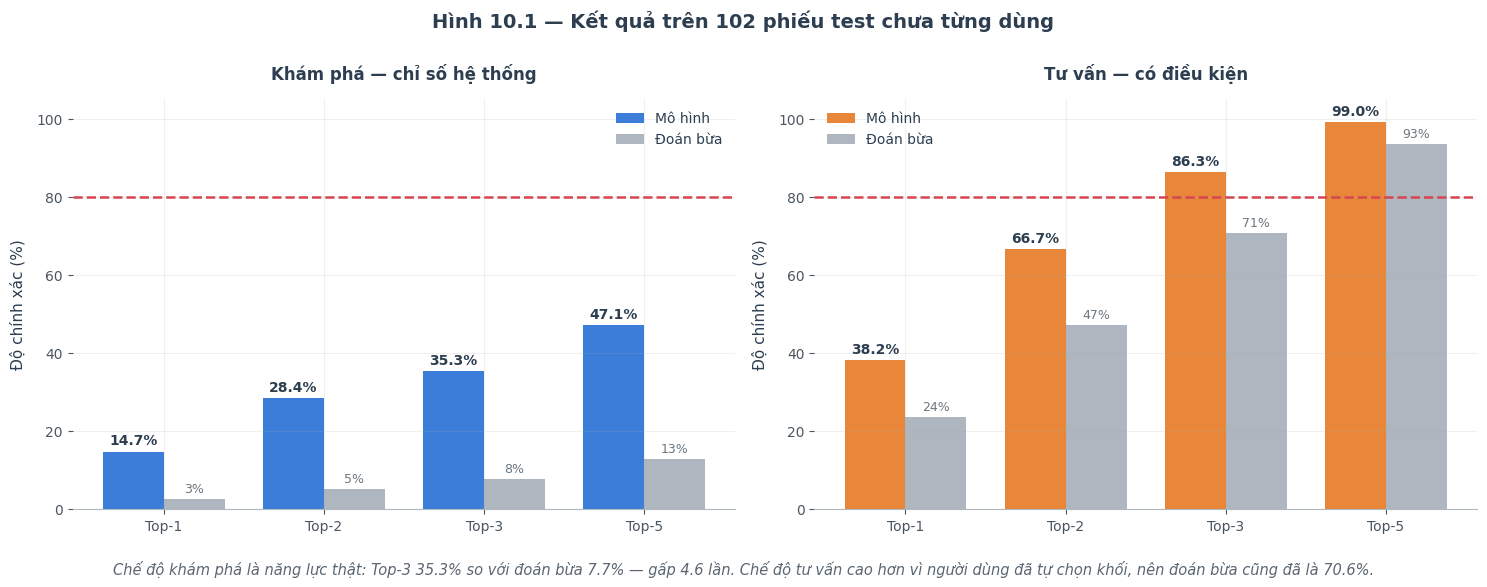

In [5]:
# ═══════════ HÌNH 10.1 — Kết quả test ═══════════
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5.4))
x = np.arange(len(TOP_K)); w = .38
for ax, (r, b, ten, mau) in zip((a1, a2), [
        (auto, bua_a, "Khám phá — chỉ số hệ thống", C_XANH),
        (guided, bua_g, "Tư vấn — có điều kiện", C_CAM)]):
    ax.bar(x - w/2, [r[k]*100 for k in TOP_K], w, color=mau, label="Mô hình")
    ax.bar(x + w/2, [b[k]*100 for k in TOP_K], w, color=C_XAM, label="Đoán bừa")
    ax.set_xticks(x); ax.set_xticklabels([f"Top-{k}" for k in TOP_K])
    ax.set_ylabel("Độ chính xác (%)"); ax.set_ylim(0, 105)
    ax.set_title(ten, fontsize=12); ax.legend()
    ax.axhline(80, color=C_THAT, ls="--", lw=1.8)
    for i, k in enumerate(TOP_K):
        ax.text(i - w/2, r[k]*100 + 1.8, f"{r[k]:.1%}", ha="center",
                fontweight="bold", fontsize=10)
        ax.text(i + w/2, b[k]*100 + 1.8, f"{b[k]:.0%}", ha="center", fontsize=9,
                color="#6B7680")
fig.suptitle(f"Hình 10.1 — Kết quả trên {len(te)} phiếu test chưa từng dùng",
             fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
luu(fig, OUT, "hinh_10_1_ket_qua.png",
    f"Chế độ khám phá là năng lực thật: Top-3 {auto[3]:.1%} so với đoán bừa {bua_a[3]:.1%} — gấp "
    f"{auto[3]/bua_a[3]:.1f} lần. Chế độ tư vấn cao hơn vì người dùng đã tự chọn khối, "
    f"nên đoán bừa cũng đã là {bua_g[3]:.1%}.")
plt.show()

   💾 hinh_10_2_train_test.png


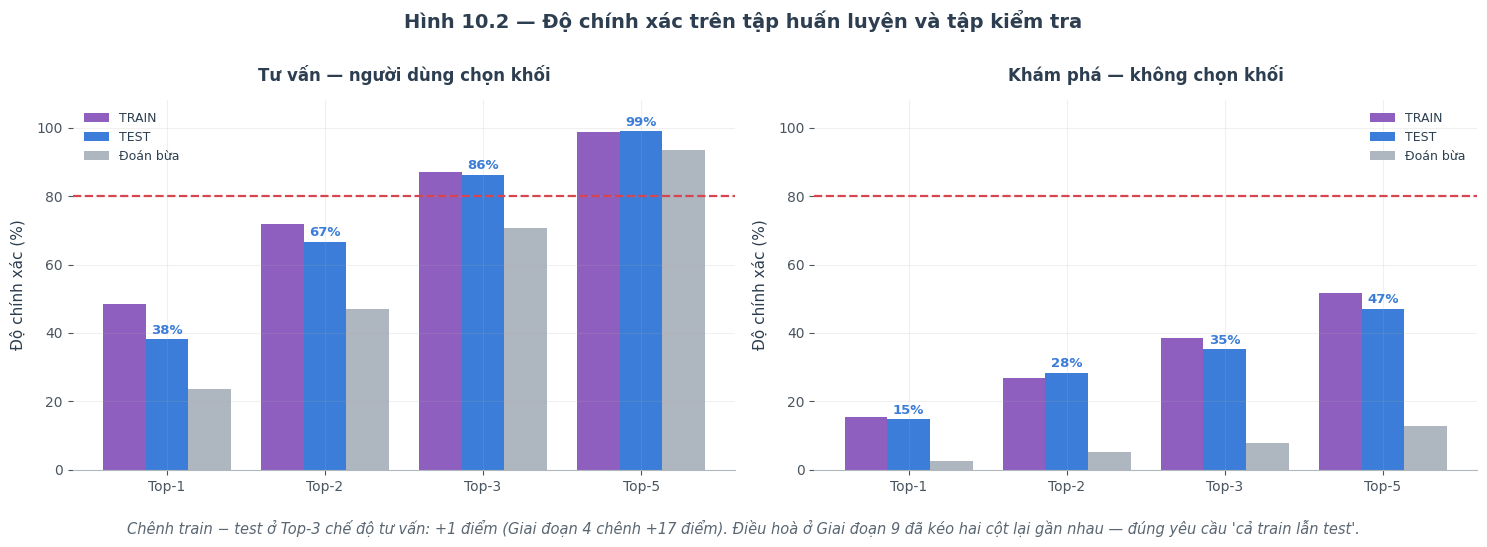

In [6]:
# ═══════════ HÌNH 10.2 — Train so với test ═══════════
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5))
x = np.arange(len(TOP_K)); w = .27
for ax, (tr_, te_, b_, ten) in zip((a1, a2), [
        (tr_guided, guided, bua_g, "Tư vấn — người dùng chọn khối"),
        (tr_auto, auto, bua_a, "Khám phá — không chọn khối")]):
    ax.bar(x - w, [tr_[k]*100 for k in TOP_K], w, color=C_TIM, label="TRAIN")
    ax.bar(x, [te_[k]*100 for k in TOP_K], w, color=C_XANH, label="TEST")
    ax.bar(x + w, [b_[k]*100 for k in TOP_K], w, color=C_XAM, label="Đoán bừa")
    ax.set_xticks(x); ax.set_xticklabels([f"Top-{k}" for k in TOP_K])
    ax.set_ylabel("Độ chính xác (%)"); ax.set_ylim(0, 108)
    ax.set_title(ten, fontsize=12); ax.legend(fontsize=9)
    ax.axhline(80, color=C_THAT, ls="--", lw=1.6)
    for i, k in enumerate(TOP_K):
        ax.text(i, te_[k]*100 + 1.6, f"{te_[k]:.0%}", ha="center",
                fontweight="bold", fontsize=9.5, color=C_XANH)
fig.suptitle("Hình 10.2 — Độ chính xác trên tập huấn luyện và tập kiểm tra",
             fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
luu(fig, OUT, "hinh_10_2_train_test.png",
    f"Chênh train − test ở Top-3 chế độ tư vấn: {(tr_guided[3]-guided[3])*100:+.0f} điểm "
    f"(Giai đoạn 4 chênh {M0['gap_train_val']['guided']['3']*100:+.0f} điểm). Điều hoà ở Giai "
    "đoạn 9 đã kéo hai cột lại gần nhau — đúng yêu cầu 'cả train lẫn test'.")
plt.show()

   💾 hinh_10_3_tien_trien.png


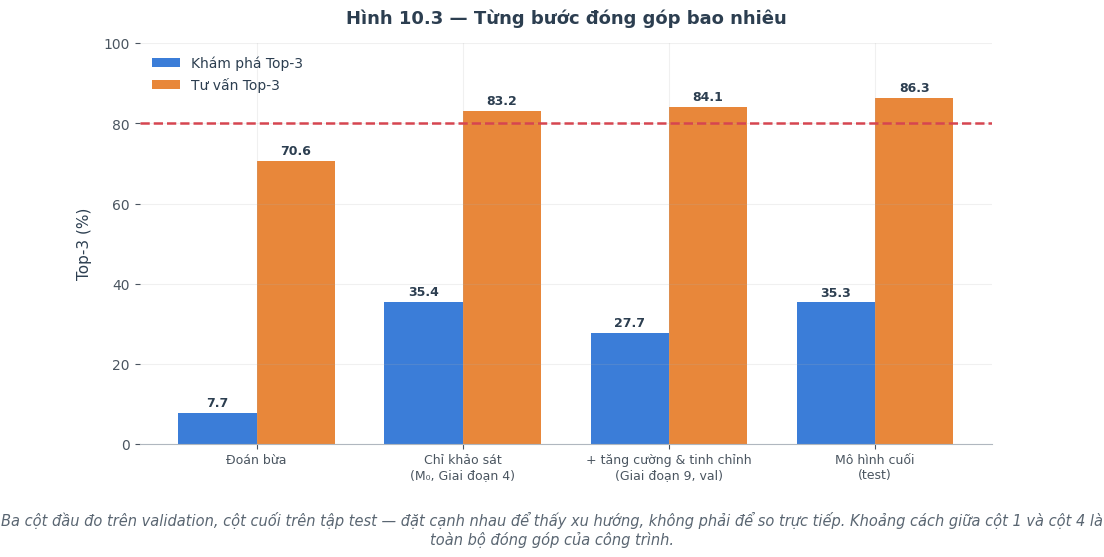

In [7]:
# ═══════════ HÌNH 10.3 — Tiến triển qua các giai đoạn ═══════════
fig, ax = plt.subplots(figsize=(11, 5.2))
buoc = ["Đoán bừa", "Chỉ khảo sát\n(M₀, Giai đoạn 4)",
        "+ tăng cường & tinh chỉnh\n(Giai đoạn 9, val)", "Mô hình cuối\n(test)"]
gt_g = [bua_g[3]*100, M0["guided"]["top"]["3"]*100,
        STH["ket_qua_cv"]["guided_top3"]*100, guided[3]*100]
gt_a = [bua_a[3]*100, M0["auto"]["top"]["3"]*100,
        STH["ket_qua_cv"]["auto_top3"]*100, auto[3]*100]
x = np.arange(len(buoc)); w = .38
ax.bar(x - w/2, gt_a, w, color=C_XANH, label="Khám phá Top-3")
ax.bar(x + w/2, gt_g, w, color=C_CAM, label="Tư vấn Top-3")
ax.set_xticks(x); ax.set_xticklabels(buoc, fontsize=9)
ax.set_ylabel("Top-3 (%)"); ax.set_ylim(0, 100)
ax.set_title("Hình 10.3 — Từng bước đóng góp bao nhiêu")
ax.legend(); ax.axhline(80, color=C_THAT, ls="--", lw=1.8)
for i in range(len(buoc)):
    ax.text(i - w/2, gt_a[i] + 1.6, f"{gt_a[i]:.1f}", ha="center", fontsize=9,
            fontweight="bold")
    ax.text(i + w/2, gt_g[i] + 1.6, f"{gt_g[i]:.1f}", ha="center", fontsize=9,
            fontweight="bold")
luu(fig, OUT, "hinh_10_3_tien_trien.png",
    "Ba cột đầu đo trên validation, cột cuối trên tập test — đặt cạnh nhau để thấy xu hướng, "
    "không phải để so trực tiếp. Khoảng cách giữa cột 1 và cột 4 là toàn bộ đóng góp của "
    "công trình.")
plt.show()

   💾 hinh_10_4_nham_lan.png


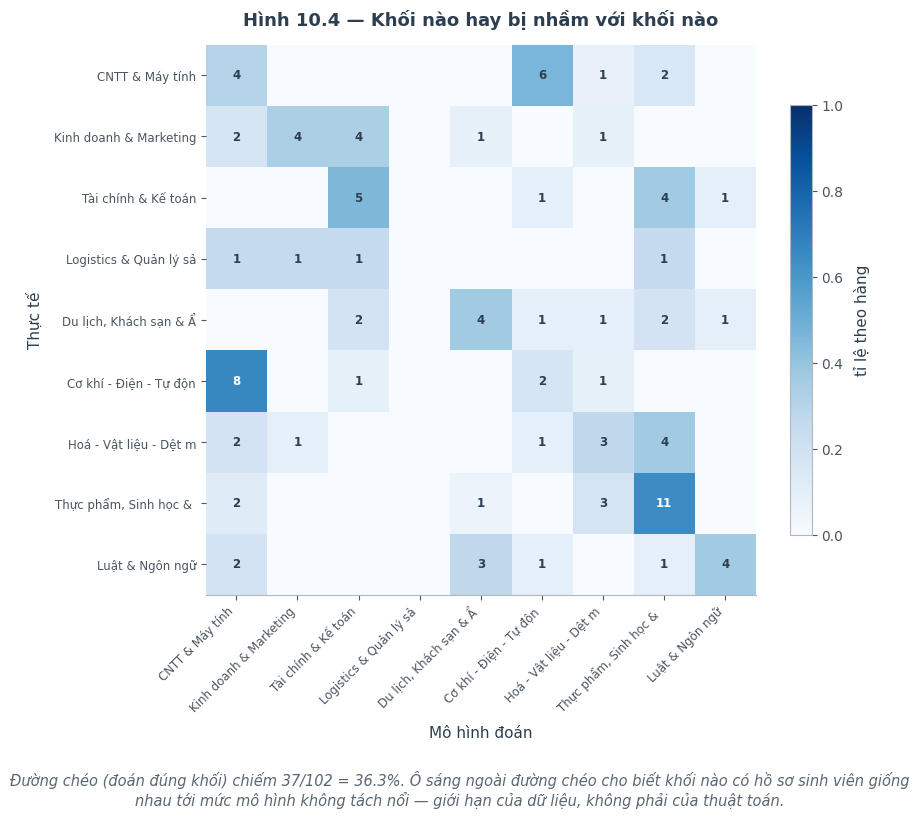

In [8]:
# ═══════════ HÌNH 10.4 — Nhầm lẫn ở mức khối ═══════════
fig, ax = plt.subplots(figsize=(9, 7.6))
cm = confusion_matrix(nhom_te, nhom_pred, labels=range(K))
cmn = cm / np.maximum(cm.sum(1, keepdims=True), 1)
im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
tn = [D["ten_nhom"][i][:22] for i in range(K)]
ax.set_xticks(range(K)); ax.set_xticklabels(tn, rotation=45, ha="right", fontsize=8.5)
ax.set_yticks(range(K)); ax.set_yticklabels(tn, fontsize=8.5)
ax.set_xlabel("Mô hình đoán"); ax.set_ylabel("Thực tế")
ax.set_title("Hình 10.4 — Khối nào hay bị nhầm với khối nào")
for i in range(K):
    for j in range(K):
        if cm[i, j]:
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8.5,
                    color="white" if cmn[i, j] > .5 else C_DAM, fontweight="bold")
ax.grid(alpha=0); fig.colorbar(im, ax=ax, shrink=.75, label="tỉ lệ theo hàng")
fig.tight_layout()
cheo = int(np.diag(cm).sum())
luu(fig, OUT, "hinh_10_4_nham_lan.png",
    f"Đường chéo (đoán đúng khối) chiếm {cheo}/{cm.sum()} = {cheo/cm.sum():.1%}. Ô sáng ngoài "
    "đường chéo cho biết khối nào có hồ sơ sinh viên giống nhau tới mức mô hình không tách nổi — "
    "giới hạn của dữ liệu, không phải của thuật toán.")
plt.show()

   💾 hinh_10_5_theo_khoi.png


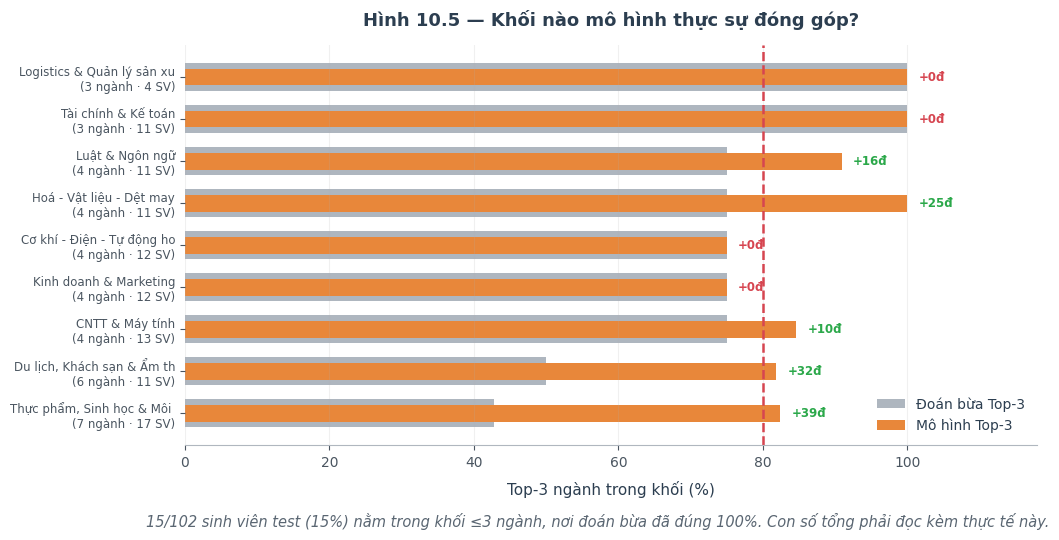

In [9]:
# ═══════════ HÌNH 10.5 — Kết quả theo khối ═══════════
theo = []
for g in range(K):
    sel = nhom_te == g
    if not sel.any():
        continue
    o = np.argsort(-S_guided[sel], 1)
    yy_ = yte[sel]
    t3 = float(np.mean([yy_[i] in NG[o[i, :3]] for i in range(int(sel.sum()))]))
    b3 = min(3, co_nhom[g]) / co_nhom[g]
    theo.append({"ma_khoi": g, "khoi": D["ten_nhom"][g], "n_nganh": int(co_nhom[g]),
                 "n_sv": int(sel.sum()), "top3": t3, "bua3": b3, "hon": t3 - b3})
dg = pd.DataFrame(theo).sort_values("n_nganh", ascending=False)
dg.to_csv(OUT / "ket_qua_theo_khoi.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 5.2))
yy = np.arange(len(dg))
ax.barh(yy, dg.bua3 * 100, color=C_XAM, height=.66, label="Đoán bừa Top-3")
ax.barh(yy, dg.top3 * 100, color=C_CAM, height=.4, label="Mô hình Top-3")
ax.axvline(80, color=C_THAT, ls="--", lw=1.8)
ax.set_yticks(yy)
ax.set_yticklabels([f"{r.khoi[:26]}\n({r.n_nganh} ngành · {r.n_sv} SV)"
                    for r in dg.itertuples()], fontsize=8.5)
ax.set_xlabel("Top-3 ngành trong khối (%)"); ax.set_xlim(0, 118)
ax.set_title("Hình 10.5 — Khối nào mô hình thực sự đóng góp?")
ax.legend(loc="lower right"); ax.grid(axis="y", alpha=0)
for i, r in enumerate(dg.itertuples()):
    ax.text(max(r.top3, r.bua3) * 100 + 1.6, i, f"{r.hon*100:+.0f}đ", va="center",
            fontsize=8.5, fontweight="bold", color=C_GA if r.hon > 0 else C_THAT)
n_de = int(dg[dg.n_nganh <= 3].n_sv.sum())
luu(fig, OUT, "hinh_10_5_theo_khoi.png",
    f"{n_de}/{len(te)} sinh viên test ({n_de/len(te):.0%}) nằm trong khối ≤3 ngành, nơi đoán bừa "
    "đã đúng 100%. Con số tổng phải đọc kèm thực tế này.")
plt.show()

## 3. Xuất mô hình và kết quả

In [10]:
MH.m.save_model(str(OUT / "model_nganh.json"))
for g, (m, _) in MH.m_nhom.items():
    m.save_model(str(OUT / f"model_khoi{g}.json"))

(OUT / "lop_va_dac_trung.json").write_text(json.dumps({
    "nganh_theo_thu_tu_lop": [int(v) for v in MH.co],
    "nganh_day_du": [int(v) for v in NG],
    "lop_theo_khoi": {str(g): [int(v) for v in co]
                      for g, (_, co) in MH.m_nhom.items()},
    "ten_dac_trung": COT,
    "diem_mu": D["diem_mu"].tolist(), "diem_sd": D["diem_sd"].tolist(),
    "to_hop": D["to_hop"],
    "nganh_to_nhom": {str(k): int(v) for k, v in D["nhom"].items()},
    "ten_nhom": {str(k): v for k, v in D["ten_nhom"].items()},
    "cach_dung": ("fieldId=None → model_nganh.json cho 39 ngành. "
                  "fieldId=k → model_khoi{k}.json rồi lấy Top-3."),
}, ensure_ascii=False, indent=2), encoding="utf-8")

metrics = {
    "ngay_chay": time.strftime("%Y-%m-%d %H:%M"), "seed": SEED,
    "cach_nhom": D["ten_cach_nhom"],
    "du_lieu": {"train_tong": len(tf), "train_that": int(tf.is_that.sum()),
                "train_tang_cuong": int((1 - tf.is_that).sum()),
                "test": len(te), "n_dac_trung": len(COT),
                "n_nganh": len(NG), "n_nhom": K, "w_that": W_THAT},
    "sieu_tham_so": {"hp": HP, "w_that": W_THAT,
                     "phan_tang": STH.get("phan_tang", {})},
    "test": {"kham_pha": {"top": auto, "bua": bua_a},
             "tu_van": {"top": guided, "bua": bua_g},
             "phang": phang, "dong_nhat": dong_nhat,
             "bua_pho_bien": bua_pb,
             "hon_pho_bien": {k: guided[k] - bua_pb[k] for k in TOP_K},
             "ky_nang_vs_pho_bien": {k: ky_nang_vs(guided[k], bua_pb[k])
                                     for k in TOP_K},
             "chi_khao_sat": {"kham_pha": chi_ks_a, "tu_van": chi_ks_g},
             **bo_sung},
    "tren_train": {"kham_pha": tr_auto, "tu_van": tr_guided},
    "chenh_train_test": {"kham_pha": {k: tr_auto[k] - auto[k] for k in TOP_K},
                         "tu_van": {k: tr_guided[k] - guided[k] for k in TOP_K}},
    "theo_khoi": dg.to_dict("records"),
    "canh_bao": ("Chỉ số hệ thống là chế độ KHÁM PHÁ. Chế độ TƯ VẤN giả định "
                 "người dùng đã chọn ĐÚNG khối nên không phải năng lực tự động."),
}
(OUT / "metrics.json").write_text(json.dumps(metrics, ensure_ascii=False, indent=2),
                                   encoding="utf-8")
pd.DataFrame([dong("khám phá", auto, bua_a),
              dong("tư vấn", guided, bua_g)]).to_csv(OUT / "bang_ket_qua.csv", index=False)

tom_tat(f"GIAI ĐOẠN 10 — KẾT QUẢ CUỐI trên {len(te)} phiếu test", [
    f"Huấn luyện trên        {len(tf):,} dòng ({int(tf.is_that.sum())} thật ×{W_THAT:.0f}"
    f" + {int((1-tf.is_that).sum()):,} tăng cường)",
    "",
    "CHẾ ĐỘ TƯ VẤN (người dùng chọn khối — chỉ số có điều kiện)",
] + [f"   Top-{k}: {guided[k]:6.1%}   bừa {bua_g[k]:5.1%}"
     f"   hơn {(guided[k]-bua_g[k])*100:+5.1f}đ" for k in TOP_K] + [
    "",
    "CHẾ ĐỘ KHÁM PHÁ (chỉ số hệ thống)",
] + [f"   Top-{k}: {auto[k]:6.1%}   bừa {bua_a[k]:5.1%}"
     f"   gấp {auto[k]/bua_a[k]:4.1f} lần" for k in TOP_K] + [
    "",
    f"Chênh train − test     tư vấn {(tr_guided[3]-guided[3])*100:+.1f}đ"
    f" · khám phá {(tr_auto[3]-auto[3])*100:+.1f}đ  (Top-3)",
    f"macro-F1 {bo_sung['auto_macro_f1']:.3f}"
    f" · balanced acc {bo_sung['auto_balanced_acc']:.3f}"
    f" · đúng khối {bo_sung['nhom_top1']:.1%}",
    "",
    f"Khối đạt 80% (Top-3)   {int((dg.top3 >= .8).sum())}/{len(dg)}",
    "",
    "SO VỚI MỐC THỰC TẾ '3 ngành phổ biến nhất' (không cần mô hình)",
] + [f"   Top-{k}: mô hình {guided[k]:6.1%}  ·  phổ biến {bua_pb[k]:6.1%}"
     f"  ·  hơn {(guided[k]-bua_pb[k])*100:+5.1f}đ" for k in TOP_K] + [
])
print(f"\n✅ model_nganh.json · {len(MH.m_nhom)} model khối · metrics.json"
      f" · bang_ket_qua.csv · 5 hình  →  {OUT}")
print(f"\nBackend dùng mô hình này: EDUTALK_MODEL_DIR={OUT.resolve()}")

╔════════════════════════════════════════════════════════════════════════════╗
║              GIAI ĐOẠN 10 — KẾT QUẢ CUỐI trên 102 phiếu test               ║
╠════════════════════════════════════════════════════════════════════════════╣
║ Huấn luyện trên        574 dòng (574 thật ×4 + 0 tăng cường)               ║
║                                                                            ║
║ CHẾ ĐỘ TƯ VẤN (người dùng chọn khối — chỉ số có điều kiện)                 ║
║    Top-1:  38.2%   bừa 23.5%   hơn +14.7đ                                  ║
║    Top-2:  66.7%   bừa 47.1%   hơn +19.6đ                                  ║
║    Top-3:  86.3%   bừa 70.6%   hơn +15.7đ                                  ║
║    Top-5:  99.0%   bừa 93.4%   hơn  +5.6đ                                  ║
║                                                                            ║
║ CHẾ ĐỘ KHÁM PHÁ (chỉ số hệ thống)                                          ║
║    Top-1:  14.7%   bừa  2.6%   gấp  5.7 lần       